<a href="https://colab.research.google.com/github/ggyupi/PCVK_Ganjil_2025/blob/main/Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection

Metode yang digunakan:

1. Template Matching
2. Edge Detection
3. Corner Detection
4. Grid Detection
5. Contour Detection

In [1]:
#import library yang dibutuhkan
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [2]:
#akses drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Template Matching**
Menggunakan library openCV
**cv.matchTemplate()**, dengan parameter
* **image**: citra input
* **templ**: template yang dicari, ukurannya tidak boleh lebih besar dari citra input
* **method**: metode dari template matching

Jenis metode template matching di openCV:
1. TM_SQDIFF
2. TM_SQDIFF_NORMED
3. TM_CCORR
4. TM_CCORR_NORMED
5. TM_CCOEFF
6. TM_CCOEFF_NORMED

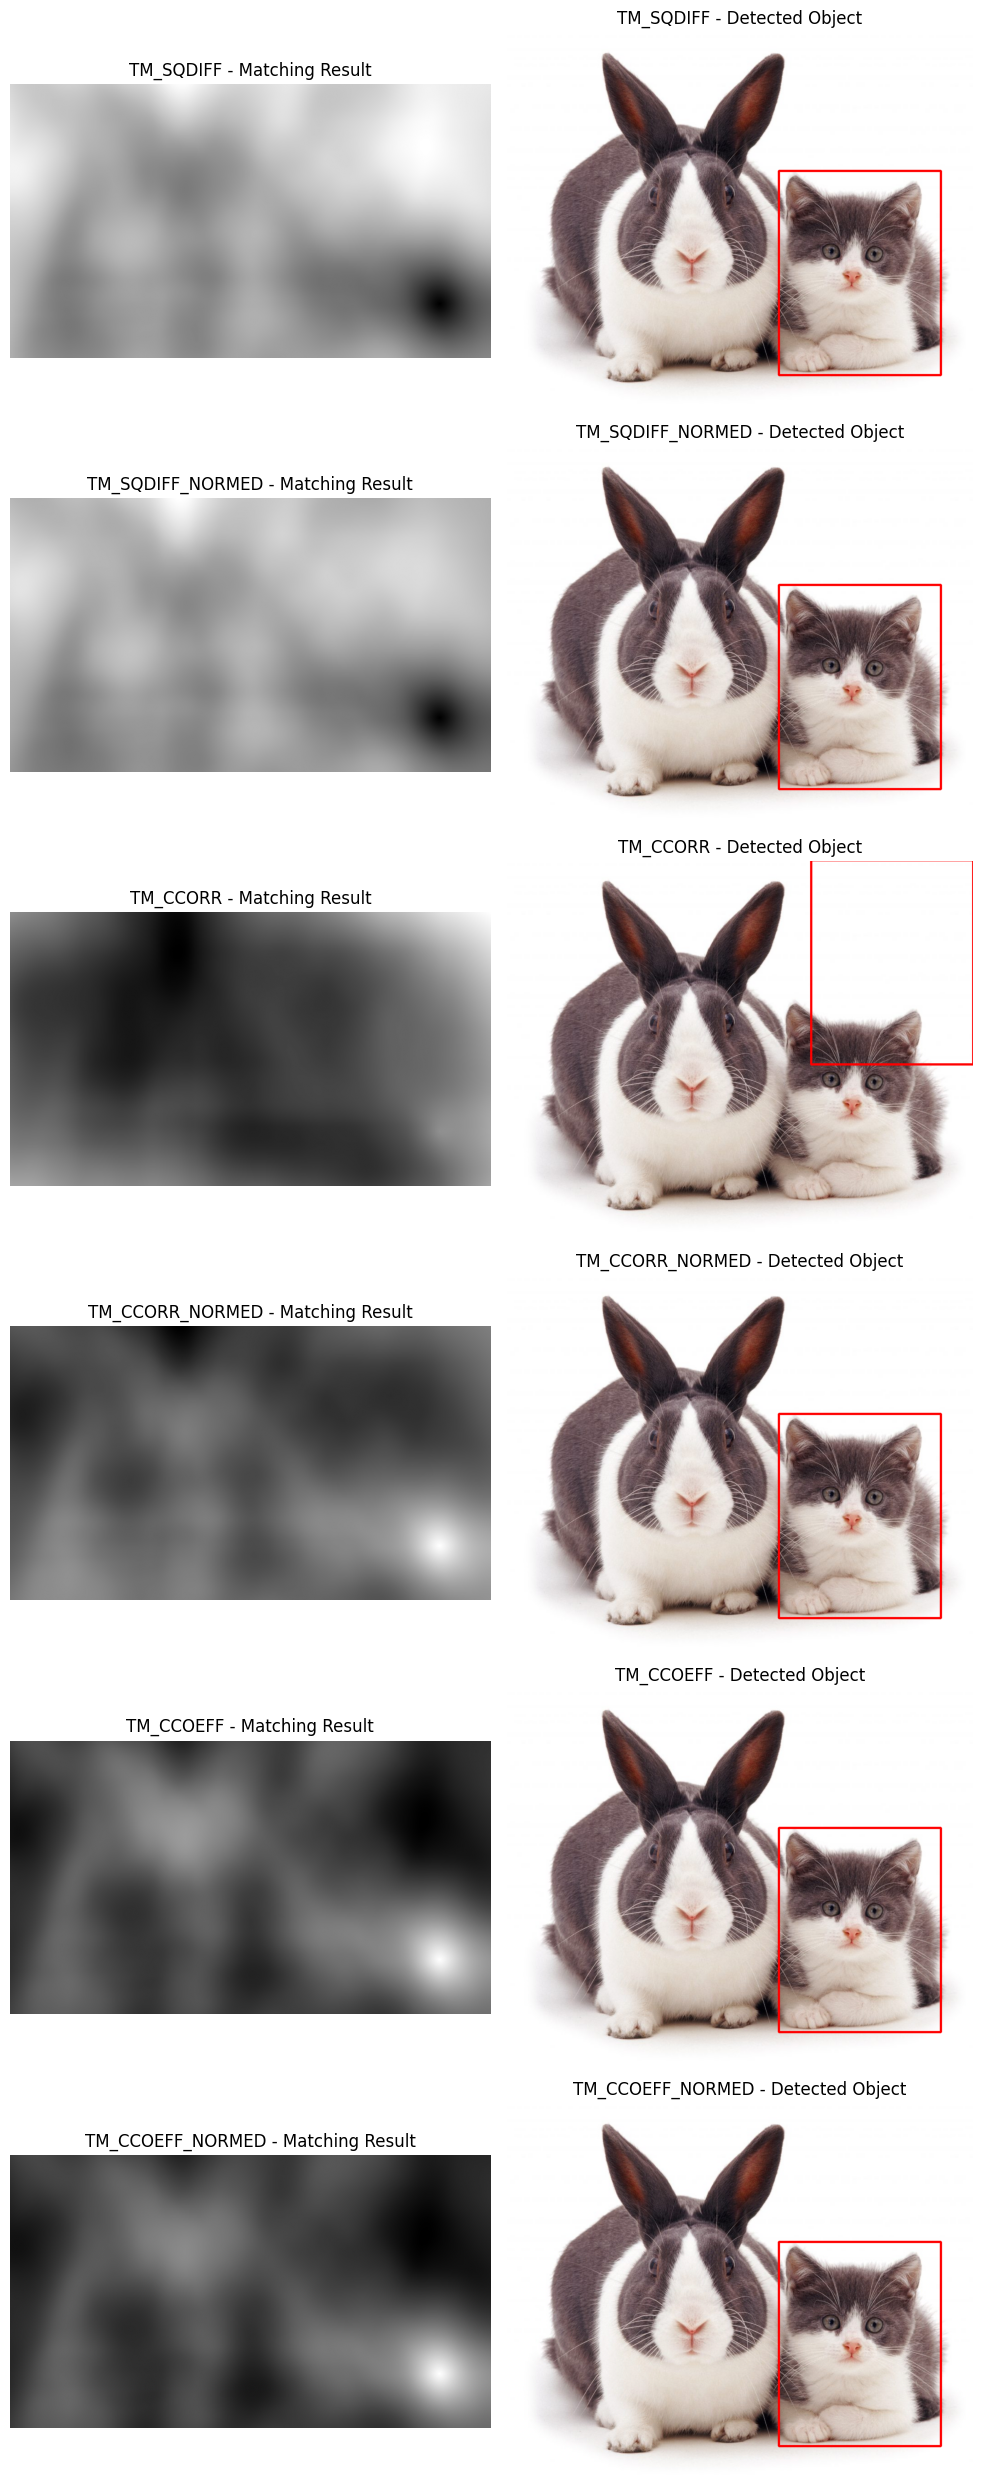

In [ ]:
# Membaca citra utama dan template
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/cats_and_bunnies.jpg')
template = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/cat2_templatejpg.jpg')


# Konversi ke grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
w, h = template_gray.shape[::-1]

# Daftar metode Template Matching
methods = [
    ('TM_SQDIFF', cv.TM_SQDIFF),
    ('TM_SQDIFF_NORMED', cv.TM_SQDIFF_NORMED),
    ('TM_CCORR', cv.TM_CCORR),
    ('TM_CCORR_NORMED', cv.TM_CCORR_NORMED),
    ('TM_CCOEFF', cv.TM_CCOEFF),
    ('TM_CCOEFF_NORMED', cv.TM_CCOEFF_NORMED)
]

# Atur ukuran figure agar hasil terlihat rapi
plt.figure(figsize=(10, 25))

for i, (name, method) in enumerate(methods, 1):
    # Template Matching
    result = cv.matchTemplate(img_gray, template_gray, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)

    # Tentukan posisi terbaik (min untuk SQDIFF, max untuk lainnya)
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    # Gambar kotak hasil deteksi
    detected_img = img.copy()
    cv.rectangle(detected_img, top_left, bottom_right, (0, 0, 255), 3)

    # Tampilkan hasil pada dua kolom (Matching & Detected)
    plt.subplot(6, 2, 2 * i - 1)
    plt.imshow(result, cmap='gray')
    plt.title(f'{name} - Matching Result')
    plt.axis('off')

    plt.subplot(6, 2, 2 * i)
    plt.imshow(cv.cvtColor(detected_img, cv.COLOR_BGR2RGB))
    plt.title(f'{name} - Detected Object')
    plt.axis('off')

plt.tight_layout()
plt.show()

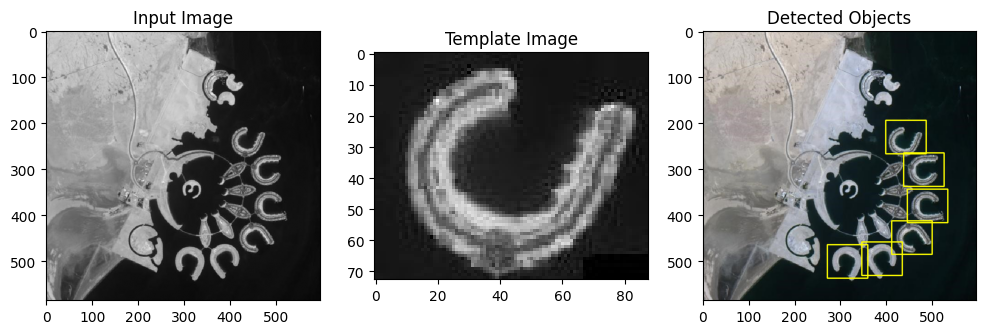

In [ ]:
# Membaca gambar input dan template
img_gray = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/bahrain.jpg', cv.IMREAD_GRAYSCALE)
template = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/bahrain-template.jpg', cv.IMREAD_GRAYSCALE)
h, w = template.shape

# Konversi ke float dan normalisasi template
img_float = img_gray.astype(np.float32)
template_float = template.astype(np.float32)
template_mean = np.mean(template_float)
template_std = np.std(template_float)
template_norm = (template_float - template_mean) / template_std

# Hitung korelasi manual
result = np.zeros((img_gray.shape[0]-h, img_gray.shape[1]-w), dtype=np.float32)
for y in range(result.shape[0]):
    for x in range(result.shape[1]):
        patch = img_float[y:y+h, x:x+w]
        patch_mean = np.mean(patch)
        patch_std = np.std(patch)
        if patch_std != 0:
            patch_norm = (patch - patch_mean) / patch_std
            result[y, x] = np.sum(patch_norm * template_norm)

# Normalisasi hasil agar 0–1
result = cv.normalize(result, None, 0, 1, cv.NORM_MINMAX)

# Threshold diturunkan agar lebih banyak cocok
threshold = 0.65
loc = np.where(result >= threshold)

# Gambar warna untuk menampilkan hasil deteksi
img_color = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/bahrain.jpg')

# Hindari kotak ganda di lokasi berdekatan
boxes = []
for pt in zip(*loc[::-1]):
    if all(abs(pt[0]-x) > w//2 or abs(pt[1]-y) > h//2 for (x, y) in boxes):
        boxes.append(pt)
        cv.rectangle(img_color, pt, (pt[0]+w, pt[1]+h), (0,255,255), 2)

# Tampilkan hasil menggunakan Matplotlib
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Input Image')

plt.subplot(1, 3, 2)
plt.imshow(template, cmap='gray')
plt.title('Template Image')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.title('Detected Objects')

plt.show()

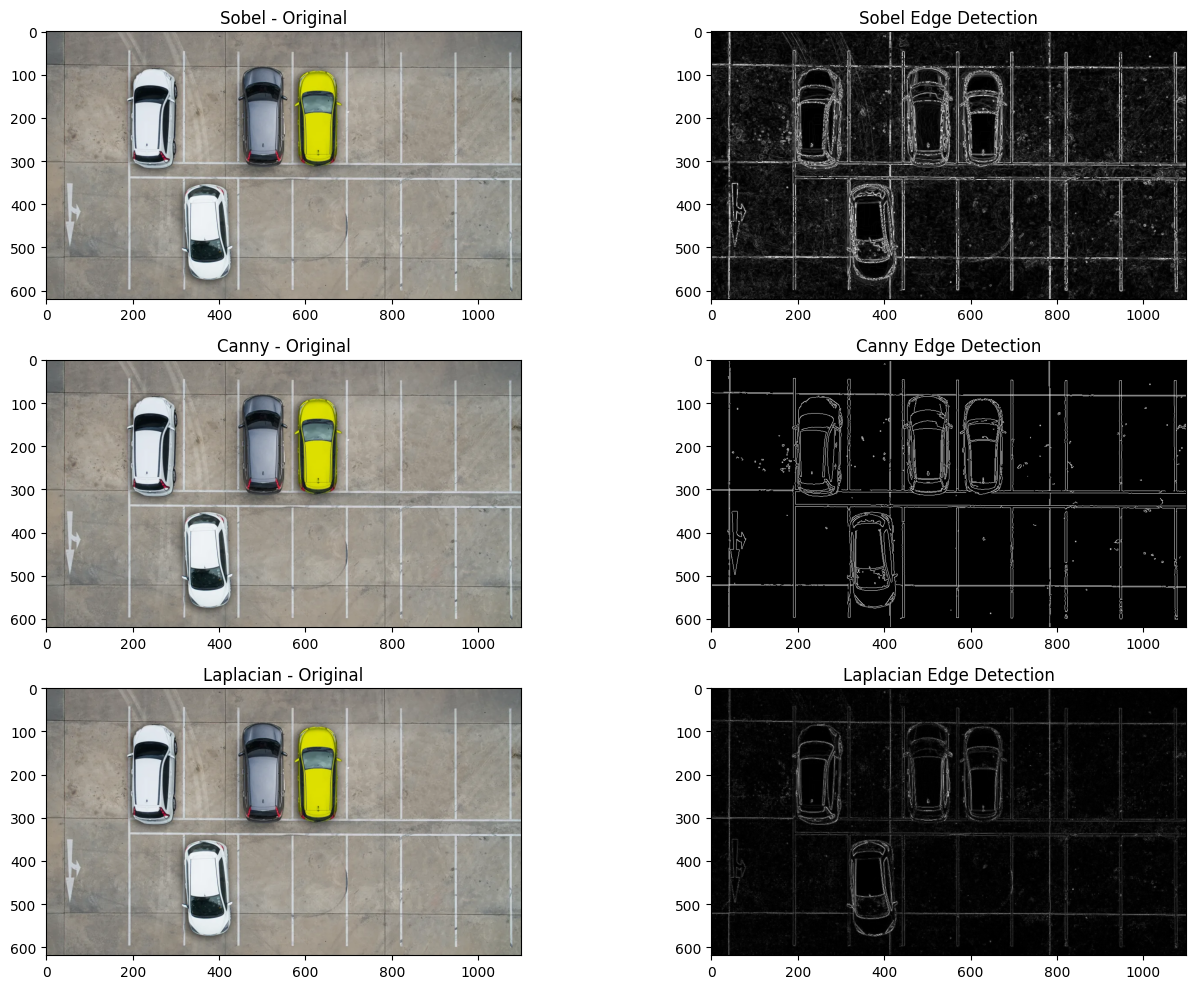

In [ ]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/car-park.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
sobel_combined = cv.magnitude(sobelx, sobely)
sobel_combined = np.uint8(np.absolute(sobel_combined))

canny = cv.Canny(gray, 100, 200)

laplacian = cv.Laplacian(gray, cv.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# ️Tampilkan hasil dengan Matplotlib
plt.figure(figsize=(14, 10))

# Sobel
plt.subplot(3, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Sobel - Original')

plt.subplot(3, 2, 2)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Edge Detection')

# Canny
plt.subplot(3, 2, 3)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Canny - Original')

plt.subplot(3, 2, 4)
plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')

# Laplacian
plt.subplot(3, 2, 5)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Laplacian - Original')

plt.subplot(3, 2, 6)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection')

plt.tight_layout()
plt.show()

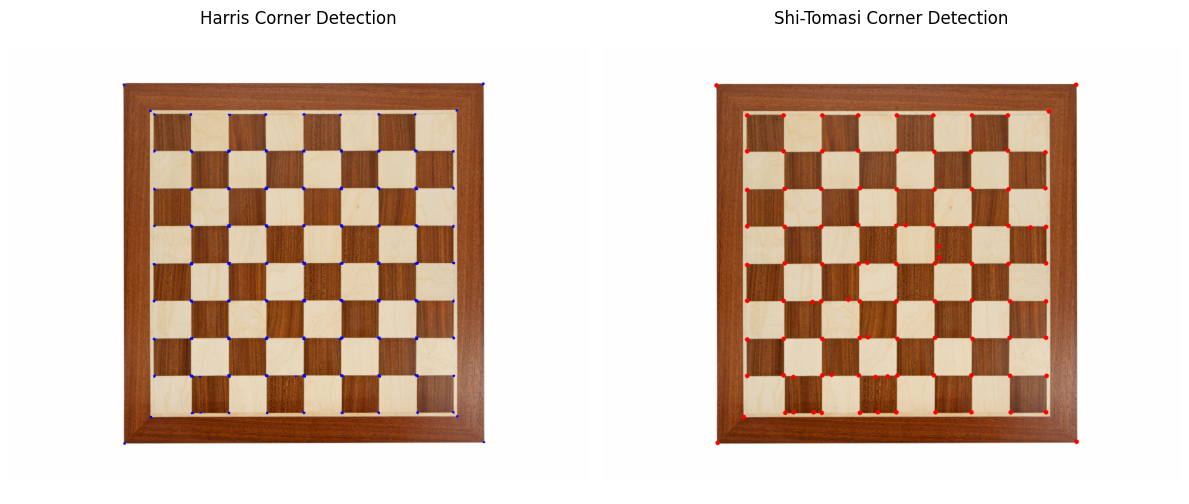

In [ ]:

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/chess-board.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray = np.float32(gray)

harris = cv.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
harris = cv.dilate(harris, None)  # memperjelas titik corner
img_harris = img.copy()
img_harris[harris > 0.01 * harris.max()] = [255, 0, 0]  # titik merah

img_shi = img.copy()
corners = cv.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = np.int32(corners)  # perbaikan dari np.int0

for i in corners:
    x, y = i.ravel()
    cv.circle(img_shi, (x, y), 4, (0, 255, 0), -1)  # titik hijau

# Tampilkan hasil dengan Matplotlib
plt.figure(figsize=(12, 6))

# Harris
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_harris, cv.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.axis('off')

# Shi-Tomasi
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_shi, cv.COLOR_BGR2RGB))
plt.title('Shi-Tomasi Corner Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

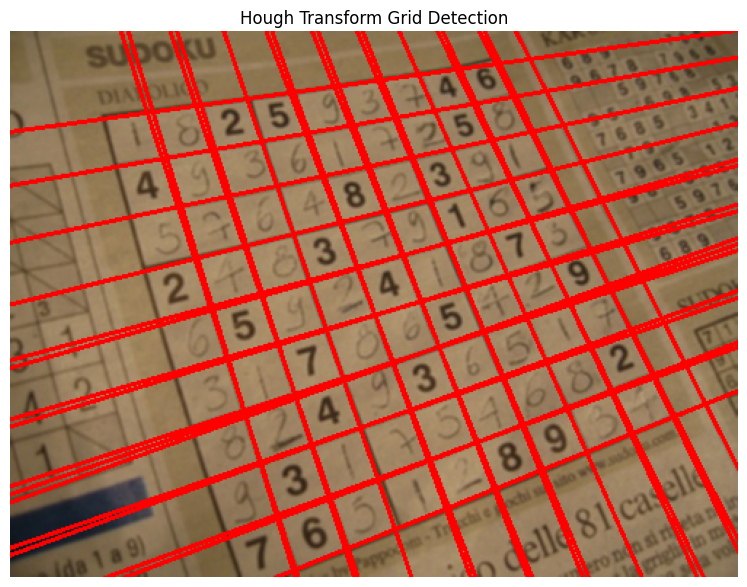

In [ ]:
# Membaca gambar sudoku
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/sudoku.jpg')

if img is None:
    print("Gambar tidak ditemukan! Pastikan path file sudah benar.")
else:
    # 1. Konversi ke grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # 2. Canny Edge Detection
    edges = cv.Canny(gray, 50, 150, apertureSize=3)

    kernel = np.ones((3, 3), np.uint8)

    # 3. Dilasi
    edges = cv.dilate(edges, kernel, iterations=1)

    # 4. Erosi
    edges = cv.erode(edges, kernel, iterations=1)

    # 5. Deteksi garis dengan Hough Transform
    lines = cv.HoughLines(edges, 1, np.pi / 180, 285)

    # Salin gambar asli untuk hasil visualisasi
    img_hough = img.copy()

    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv.line(img_hough, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # 6. Tampilkan hasil
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(img_hough, cv.COLOR_BGR2RGB))
    plt.title('Hough Transform Grid Detection')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


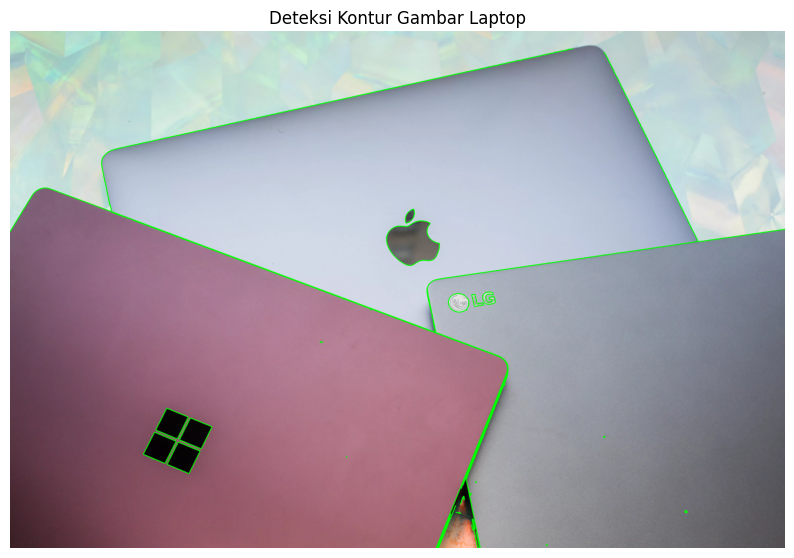

In [ ]:
# 1. Membaca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/laptop.jpg')

# Salin gambar untuk menggambar kontur nanti
img_contour = img.copy()

# 2. Ubah ke grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 3. Deteksi tepi menggunakan Canny
edged = cv.Canny(gray, 30, 200)

# 4. Menemukan kontur terluar
contours, hierarchy = cv.findContours(edged, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

# 5. Menggambar semua kontur pada gambar asli
cv.drawContours(img_contour, contours, -1, (0, 255, 0), 3)

# 6. Menampilkan hasil menggunakan Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(img_contour, cv.COLOR_BGR2RGB))
plt.title('Deteksi Kontur Gambar Laptop')
plt.axis('off')
plt.show()

# D2. Praktikum Feature Matching dan Face Detection

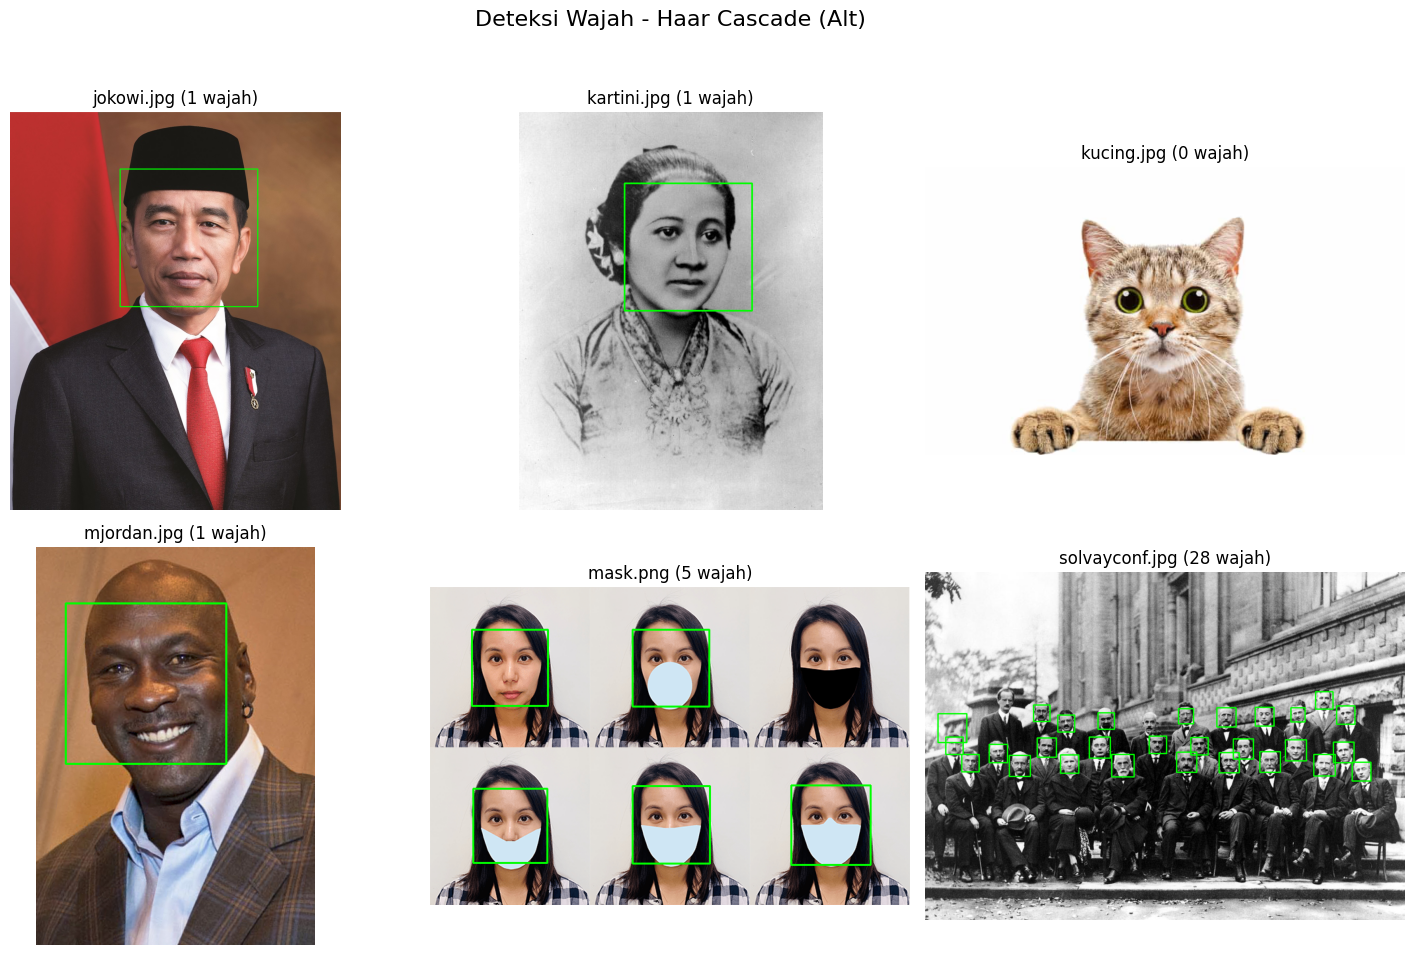

In [ ]:
# Path folder utama
base_path = '/content/drive/MyDrive/PCVK'

# Daftar gambar yang akan diuji
image_files = ['jokowi.jpg', 'kartini.jpg', 'kucing.jpg', 'mjordan.jpg', 'mask.png', 'solvayconf.jpg']

# Load model Haar Cascade alternatif
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalface_alt.xml')

# Ukuran tampilan
plt.figure(figsize=(15, 10))

# Loop tiap gambar
for i, filename in enumerate(image_files):
    img = cv.imread(f'{base_path}/facedet/{filename}')
    if img is None:
        print(f"Gagal memuat {filename}")
        continue

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Deteksi wajah
    faces = cascade_wajah.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

    # Gambar kotak hijau pada wajah
    for (x, y, w, h) in faces:
        cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Tampilkan hasil
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f"{filename} ({len(faces)} wajah)")
    plt.axis('off')

plt.suptitle('Deteksi Wajah - Haar Cascade (Alt)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


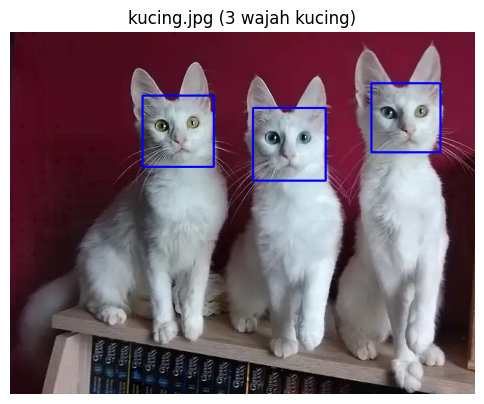

In [ ]:
# Path folder utama
base_path = '/content/drive/MyDrive/PCVK'

# Load model Haar Cascade khusus wajah kucing
cascade_kucing = cv.CascadeClassifier(f'{base_path}/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalcatface.xml')

# Baca gambar kucing
img = cv.imread(f'{base_path}/facedet/kucing2.jpg')
if img is None:
    print("Gagal memuat gambar kucing.jpg")
else:
    # Ubah ke grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Deteksi wajah kucing
    cat_faces = cascade_kucing.detectMultiScale(gray, scaleFactor=1.03, minNeighbors=3)

    # Gambar kotak biru pada wajah kucing
    for (x, y, w, h) in cat_faces:
        cv.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Tampilkan hasil
    plt.figure(figsize=(6, 6))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f"kucing.jpg ({len(cat_faces)} wajah kucing)")
    plt.axis('off')
    plt.show()

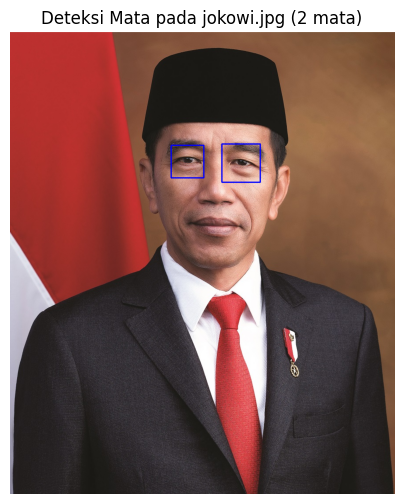

In [ ]:
# Path dasar
base_path = '/content/drive/MyDrive/PCVK'

# Muat model deteksi mata
eye_cascade = cv.CascadeClassifier(f'{base_path}/haarcascades/haarcascade_eye.xml')

# Baca gambar Jokowi
img = cv.imread(f'{base_path}/facedet/jokowi.jpg')
if img is None:
    print("Gagal memuat gambar jokowi.jpg")
else:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Deteksi mata
    eyes = eye_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

    # Gambar kotak biru pada setiap mata yang terdeteksi
    for (x, y, w, h) in eyes:
        cv.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Tampilkan hasil
    plt.figure(figsize=(6, 6))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f"Deteksi Mata pada jokowi.jpg ({len(eyes)} mata)")
    plt.axis('off')
    plt.show()

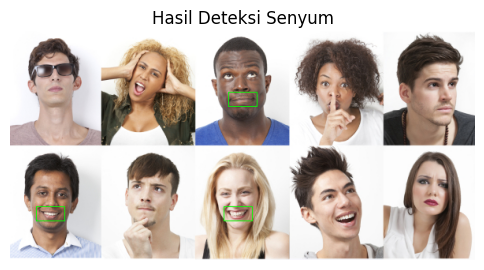

In [ ]:
# Path dasar
base_path = '/content/drive/MyDrive/PCVK'

# Muat model Haar Cascade untuk deteksi senyum
cascade_senyum = cv.CascadeClassifier(f'{base_path}/haarcascades/haarcascade_smile.xml')

# Baca gambar
img = cv.imread(f'{base_path}/facedet/people.jpg')
if img is None:
    print("Gambar tidak ditemukan! Pastikan path sudah benar.")
else:
    # Deteksi senyum
    roi_senyum = cascade_senyum.detectMultiScale(
        img,
        scaleFactor=1.3,
        minNeighbors=7,
        minSize=(5, 5)
    )

    # Gambar kotak hijau pada hasil deteksi
    for (x, y, w, h) in roi_senyum:
        cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 1)

    # Tampilkan hasil
    plt.figure(figsize=(6, 6))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title("Hasil Deteksi Senyum")
    plt.axis('off')
    plt.show()

In [ ]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes


  # initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename


  try:
    filename = take_photo('photo.jpg')
    print('Saved to {}'.format(filename))

    # Show the image which was just taken.
    display(Image(filename))
  except Exception as err:
    # Errors will be thrown if the user does not have a webcam or if they do not
    # grant the page permission to access it.
    print(str(err))


  # JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "Status:";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '' +
          'When finished, click here or on the video to stop this demo';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data


  # start streaming video from webcam
video_stream()
# label for video
label_html = 'Capturing...'
# initialze bounding box to empty
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # convert JS response to OpenCV Image
    img = js_to_image(js_reply["img"])

    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # grayscale image for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # get face region coordinates
    faces = face_cascade.detectMultiScale(gray)
    # get face bounding box for overlay
    for (x,y,w,h) in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes


<IPython.core.display.Javascript object>

/tmp/ipython-input-265856589.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


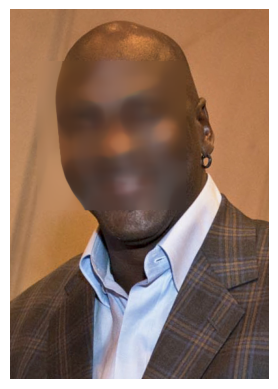

In [ ]:
# Path dasar dan file
base_path = '/content/drive/MyDrive/PCVK'
cascade_path = f'{base_path}/haarcascades/haarcascade_frontalface_alt.xml'
image_path = f'{base_path}/facedet/mjordan.jpg'

# Load classifier dan gambar
face_cascade = cv.CascadeClassifier(cascade_path)
img = cv.imread(image_path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Deteksi wajah
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# Blurring pada setiap wajah yang terdeteksi
for (x, y, w, h) in faces:
    roi = img[y:y+h, x:x+w]
    roi_blur = cv.medianBlur(roi, 35)
    img[y:y+h, x:x+w] = roi_blur

# Konversi BGR → RGB sebelum ditampilkan
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Tampilkan hasil
plt.imshow(img_rgb)
plt.axis('off')
plt.show()


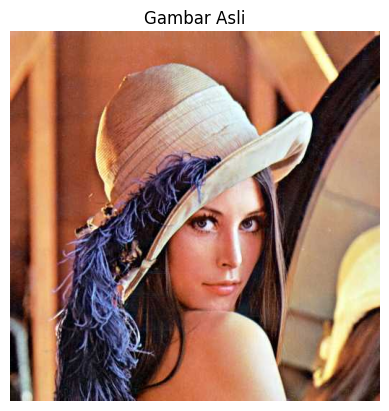

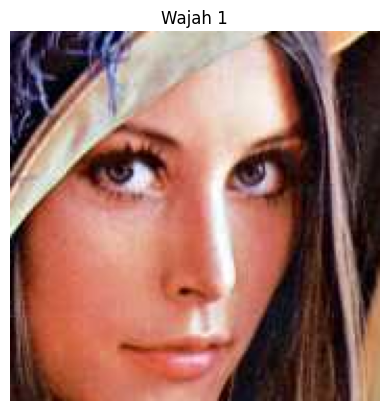

In [12]:
# Path dasar folder
base_path = '/content/drive/MyDrive/PCVK/Images'

# Load file Haar Cascade untuk deteksi wajah
cascade = cv.CascadeClassifier(f'{base_path}/haarcascades/haarcascade_frontalface_alt.xml')

# Baca gambar target
img = cv.imread(f'{base_path}/lena.jpg')

# Deteksi wajah pada gambar
faces = cascade.detectMultiScale(
    img,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

# Tampilkan gambar asli
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis("off")
plt.show()

# Tampilkan tiap wajah hasil deteksi
for i, (x, y, w, h) in enumerate(faces, 1):
    wajah = img[y:y+h, x:x+w]  # potong area wajah
    plt.imshow(cv.cvtColor(wajah, cv.COLOR_BGR2RGB))
    plt.title(f"Wajah {i}")
    plt.axis("off")
    plt.show()